# Complexity analysis through time

During our first analysis of the shadowing phenomena over pip environment, we noticed an increasing linear pattern of such phenomena over time (from 2016 to 2025). Starting from this result, we decide to investigate if this linear growing is linked in some way with an increasing of the package complexity (e.g. LOC, cyclomatic complexity, nesting depth, total number of dependencies and the depth of dependency tree)

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
DATA_PATH = "../../data/complexity/complexity.csv"

df  = pd.read_csv(DATA_PATH)

df.dropna(inplace=True)

df

,package,file,year,lloc,cyclomatic_complexity,max_scope_nesting_level,total_dependencies,max_dependencies_depth
0,azureml-contrib-reinforcementlearning,./tests/__init__.py,2025,0,0,1,62,10
1,azureml-contrib-reinforcementlearning,./tests/run_unit_tests_using_tox.py,2025,28,0,1,62,10
2,azureml-contrib-reinforcementlearning,./tests/run_coverage_analysis.py,2025,9,0,1,62,10
3,azureml-contrib-reinforcementlearning,./tests/tests_gated_script.py,2025,38,3,2,62,10
4,azureml-contrib-reinforcementlearning,./azureml/__init__.py,2025,9,0,2,62,10
...,...,...,...,...,...,...,...,...
4586,django-zesty-metrics,./zesty_metrics/views.py,2016,92,45,4,8,3
4587,django-zesty-metrics,./zesty_metrics/migrations/__init__.py,2016,0,0,1,8,3
4588,django-zesty-metrics,./zesty_metrics/migrations/0001_initial.py,2016,13,5,3,8,3
4589,django-zesty-metrics,./zesty_metrics/migrations/0002_auto__add_dail...,2016,15,5,3,8,3


In [64]:
# wrangling dataframe to have it package-wise
df_packages = df.groupby(["year", "package"]).agg(
    lloc = ("lloc", "sum"),
    cyclomatic_complexity = ("cyclomatic_complexity", "sum"),
    max_scope_nesting_level = ("max_scope_nesting_level", "mean"),
    total_dependencies = ("total_dependencies", "max"),
    max_dependencies_depth = ("max_dependencies_depth", "max")
)

df_packages

lloc  cyclomatic_complexity  \
year package                                                                
2016 django-zesty-metrics                      741                    291   
2017 falafel                                     3                      1   
     itc-cli                                  1969                    573   
2018 jw-grbackup                               240                     68   
     liform                                   2398                   1414   
2019 homeassistant                          288943                 112535   
     ws2801-rpi                                359                     91   
2020 gerapy                                   2098                    645   
     overpass2                                 185                    103   
2021 clicksql                                 1811                    852   
     sphinx-prompt                             252                    122   
2022 pydid                                     945                    390   
     tacker-horizon                           4695                   1736   
2023 globus-compute-common                     920                    413   
     rust                                     2107                    484   
2024 confine-controller                      18390                   6548   
     unionmeta-byoc                              0                      0   
2025 azureml-contrib-reinforcementlearning    1513                    679   
     fortilib                                 2086                   1211   

                                            max_scope_nesting_level  \
year package                                                          
2016 django-zesty-metrics                                  2.400000   
2017 falafel                                               1.500000   
     itc-cli                                               2.500000   
2018 jw-grbackup                                           2.500000   
     liform                                                2.850000   
2019 homeassistant                                         2.847430   
     ws2801-rpi                                            1.857143   
2020 gerapy                                                2.285714   
     overpass2                                             2.800000   
2021 clicksql                                              2.594595   
     sphinx-prompt                                         3.000000   
2022 pydid                                                 3.000000   
     tacker-horizon                                        2.535211   
2023 globus-compute-common                                 2.514286   
     rust                                                  2.727273   
2024 confine-controller                                    2.624542   
     unionmeta-byoc                                        1.000000   
2025 azureml-contrib-reinforcementlearning                 2.405405   
     fortilib                                              3.125000   

                                            total_dependencies  \
year package                                                     
2016 django-zesty-metrics                                    8   
2017 falafel                                                 1   
     itc-cli                                                -1   
2018 jw-grbackup                                            13   
     liform                                                 18   
2019 homeassistant                                          -1   
     ws2801-rpi                                             -1   
2020 gerapy                                                 71   
     overpass2                                               7   
2021 clicksql                                                1   
     sphinx-prompt                                          23   
2022 pydid                                                   7   
     tacker-

In [78]:
def draw_complexity_stats(data, x_col, y_col, x_label, y_label, title):
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=data, x=x_col, y=y_col)

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

df_packages_plot = df_packages.reset_index() # reset the index to be able to plot it easily using year as x-axis

In [66]:
df_packages_plot.groupby("year").size().reset_index(name="count")

,year,count
0,2016,1
1,2017,2
2,2018,2
3,2019,2
4,2020,2
5,2021,2
6,2022,2
7,2023,2
8,2024,2
9,2025,2


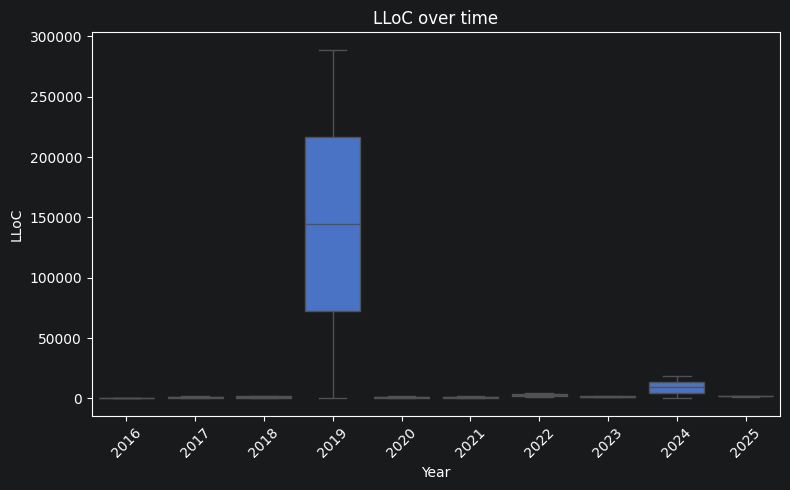

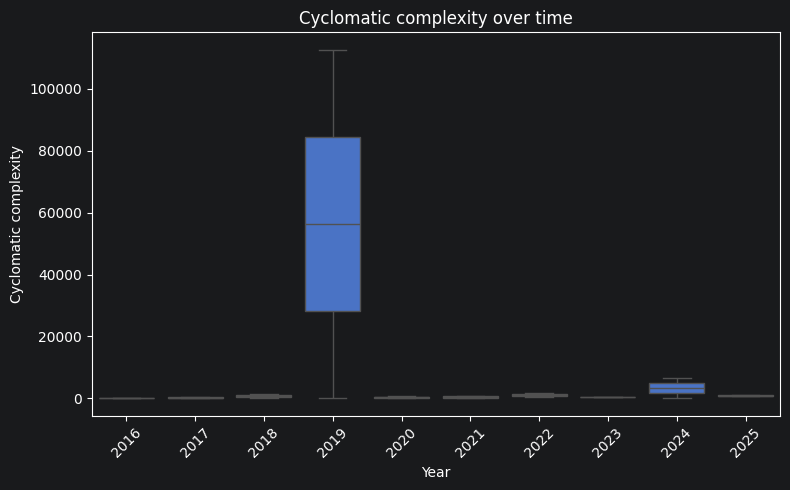

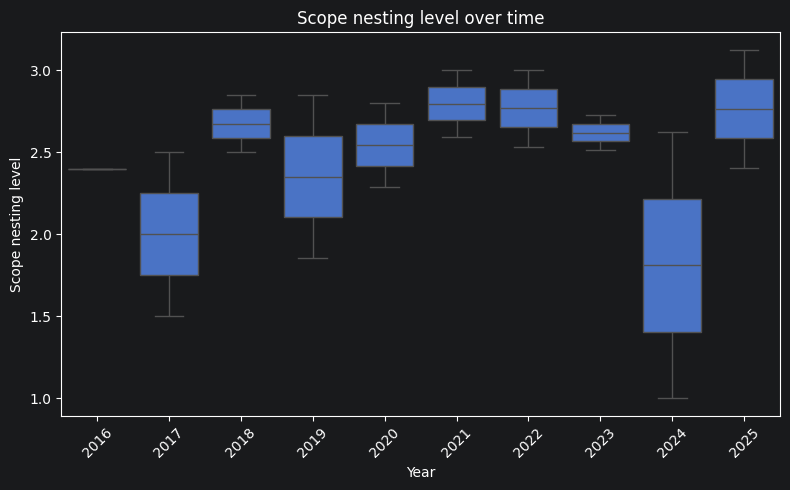

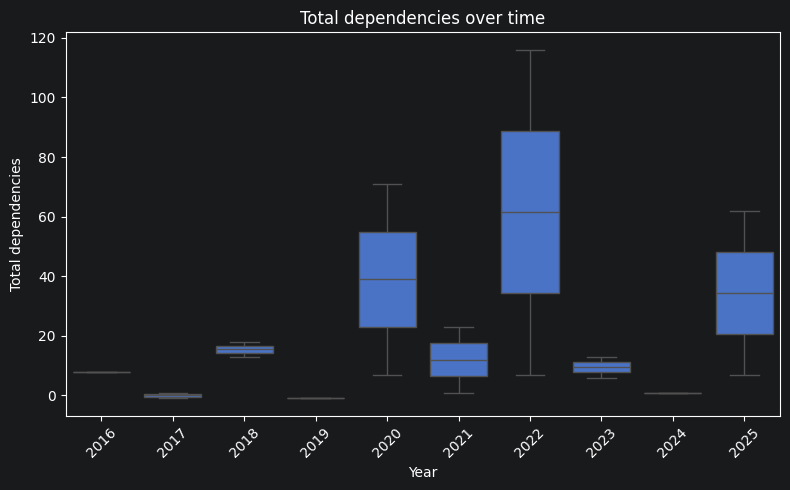

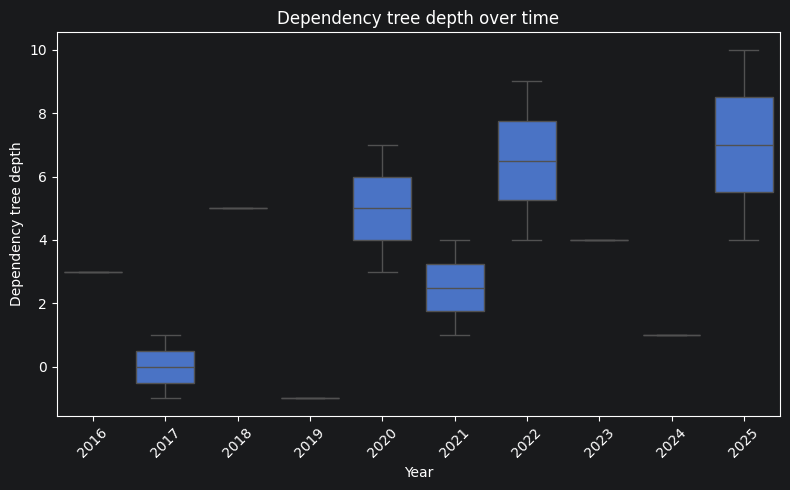

In [79]:
draw_complexity_stats(df_packages_plot, "year", "lloc", "Year", "LLoC", "LLoC over time")
draw_complexity_stats(df_packages_plot, "year", "cyclomatic_complexity", "Year", "Cyclomatic complexity", "Cyclomatic complexity over time")
draw_complexity_stats(df_packages_plot, "year", "max_scope_nesting_level", "Year", "Scope nesting level", "Scope nesting level over time")
draw_complexity_stats(df_packages_plot, "year", "total_dependencies", "Year", "Total dependencies", "Total dependencies over time")
draw_complexity_stats(df_packages_plot, "year", "max_dependencies_depth", "Year", "Dependency tree depth", "Dependency tree depth over time")